# PHYS20762 - Project 3 - Monte Carlo Techniques, Neutron Transport and Scattering Through a Shielding Layer
Celeste Troncone 11528844<br>
University of Manchester<br>
March 2026

## Introduction
Thermal neutrons interact with matter through scattering and absorption, meaning neutron interactions with matter are pertinent to shielding physics and reactor engineering. During neutron transport, a particle will undergo one of three mechanisms: it will either be absorbed by a nucleus, scattered so that it's trajectory changes, reflected out or transmitted through the material. The probability of one of these interactions happening is dependent on the microscopic interaction cross-section, as well as the bulk properties intrinsic to the material.

Neutron interactions in matter are by nature stochastic, meaning that they obey a random distribution and thus can be analysed statistically. Monte Carlo techniques are used for modelling particle histories because they randomly sample small steps and scattering outcomes, thus simulating isotropic scattering. This is a much more viable method than trying to analytically solve a neutron transport equation. Monte Carlo is useful because it allows one to simulate an integer number, $N$, neutron histories through which macroscopic properties like transmission, reflection and absorption probabilities can be calculated. 

In this project, a Monte Carlo simulation was used to model neutron transport and scattering through a shielding layer, a slab, or thickness $L$. The simulation statistically analysed the neutron histories through three different materials, notably water, graphite and lead. Neutron motion was modelled as a three-dimensional random walk, where the distance between subsequent steps follows an exponential distribution governed by the mean-free path of the material. For each step, a binning algorithm was used; neutrons are either absorbed, scattered or transmitted following an interaction and the count on each bin increased accordingly.

In order to model the stochastic nature of neutron transport, it was first important to generate isotropic direction vectors and exponentially distributed mean-free path lengths. These isotropic directions are then applied to simulate the neutron histories through slabs of varying thicknesses, in order to determine the relationship between slab thickness and interaction rates. From this, the Beer-Lambert law is linearised and applied to the transmission fraction against slab thickness graph in order to determine attenuation lengths for each material. Attenuation refers to the reduction in flux lost following a neutron's interaction with matter. Following this analysis, a comparison is drawn between this initial method and Woodcock's method, wherein a fictitious path is introduced and we consider a slab with a two-material interface.

A brief overview of the project is thus to demonstrate how Monte Carlo methods can accurately reproduce the stochastic nature of neutron transport through a shielding layer.

## Theory

### Neutron Interactions in Matter
Neutrons propagating through matter interact via absorption or scattering. Absorption removes the neutron permanently, whereas scattering changes the trajectory of the neutron. Scattering results in either reflection or transmission; this process is dependent on the probability of each interaction, determined themselves by bulk material properties.

Particle absorption is governed by the number of absorbing molecules, number of neutrons absorbed, the rate of absorption per unit thickness and the intensity variation with thickness. These relationships can be easily derived by considering a slab of a thickness $dx$ and cross-section $dA$. First, we must consider the number of absorbing molecules, governed by the equation
$$n=\frac{\rho N_A}{M}$$ 
where $\rho$ is the density of the slab, $N_A$ is Avogadro's constant and $M$ is the molar mass. It is easy to believe then that the total numeber of neutrons absorbed must be related to the fraction of absoribing molecules.

The microscopic cross-sections are converted into macroscopic cross-sections through
$$\Sigma_a = n\sigma_a$$
$$\Sigma_s = n\sigma_s$$
such that the total interaction probability is
$$\Sigma_t = \Sigma_s + \Sigma_a$$
and the corresponding mean-free path is
$$\lambda = \frac{1}{\Sigma_t} $$
which represents the average distance travelled by a neutron between successive interactions.

### Exponential attenuation
Neutron attenuation follows an exponential law called the Beer-Lambert Law; throughout the project the cross-section and thus interactions probabilities are assumed to be constant with energy, which simplifies the problem at hand. Neutron interactions form a Poisson process, so if we consider a slab of thickness $dx$, the change in neutron intensity with respect to the thickness is
$$-\frac{dI}{dx} = n\sigma I = \Sigma_t I $$ 
This differential equation can be rearranged to form an equation that demonstrates the intensity varies with thickness as follows
$$I(x)=I_0e^{-\Sigma_t x}.$$
This relation predicts that neutron transmission decreases exponentially as the thickness of the slab increases.

### Shielding Behaviour
Neutron shielding is defined as the reduction of neutron flux during the propagation of particles through a material. Flux reduction occurs to the interaction mechanisms that occur due to the bulk macroscopic properties of the material. 

As neutrons travel through a slab, the probability of survival reduces exponentially and is governed by the mean free path. This means that thicker slabs reduce the probability of transmission, instead increasing the likelihood of backscattering or absorption. The effect of shielding material is thus determined by its macroscopic cross-sections, such that materials with large absorption cross-sections attenuate flux at a faster rate.

Shielding has many applications, such as nuclear energy, medical radiology and particle accelerators. In nuclear reactors for example, the primary role of shielding is to absorb fast and thermal neutrons so that neutron flux remains below a certain threshold and thus protects sensitive equipment. Shielding is also used for reactor control, as thermal neutrons have a high probility of inducing fission in $235U$; graphite, water and concrete are often used for such applications.

### Monte Carlo Simulation
In the simulation, neutrons are modelled using a three-dimensional random walk. The distance between subsequent steps is modelled by exponential distributing as such $\sim e^{\frac{-x}{\lambda}}$, where $\lambda$ is the mean free path of the material. 

At each step, neutrons are either absorbed or scattered according to the probabilities
$$P_a = \frac{\Sigma_a}{\Sigma_t},   P_s = \frac{\Sigma_s}{\Sigma_t}$$
where the symbols hold the same meanings as before. If the neutron is absorbed, the path ends. If the neutron survives, a new isotropic distance is assigned and the particle is either reflected or transmitted. This repeats until the neutron is absorbed by the slab, resulting in "death", or escape the slab by transmission or reflection. This can be visualised by a Markov Chain, which visualises the particle histories.

## Random number generation
Monte Carlo simulations are reliant on the generation of random, uniformly distributed numbers to model stochastic processes such as neutron scattering. Neutron interactions are determined by the interaction probabilities and the probability of survival is decreases exponentially with every step. Though neutron trajectories are not deterministic, a random number generator with no bias or correlation accurately mirrors the expected behaviour of neutron interactions in a shielding layer.

In [1]:
# Initialisation
import numpy as np
import matplotlib.pyplot as plt
import random
from ipywidgets import interact
from mpl_toolkits.mplot3d import Axes3D
%matplotlib ipympl  

def random_number_array(n, m):
    """
    Generates a random number array in specified range
    """
    array = []
    for i in range(0,n):
        rand_num = np.random.uniform(1,m)
        array.append(int(np.round(rand_num,0)))
    return array 

def plot_scatter(n):
    """
    Plots an interactive scatter with no spectral issues (X, Y, Z are uncorrelated and uniformly distributed).
    """
    # use function for all axes
    X = random_number_array(n,1000)
    Y = random_number_array(n,1000)
    Z = random_number_array(n,1000)

    # create figure and 3D axis
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(111, projection='3d')

    # scatter plot
    ax.scatter3D(X, Y, Z, color='red', marker='o')

    # labels and title
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    ax.set_title('3D Scatter Plot Using Custom Random Function')

    plt.show()

# prints sliders in the notebook so the user can see the effect of varying n
_ = interact(
    plot_scatter,
    n=(500, 1000, 100)
)

interactive(children=(IntSlider(value=700, description='n', max=1000, min=500, step=100), Output()), _dom_clas…

It is evident here that there are no observable spectral correlations in the sample. The neutron positions in cartesian three-dimensional space appear to be statistically independent. This conclusion can be drawn by observing that there are no poles, clustering or directional bias. The volume is filled uniformly by the neutrons, which physically is consistent with isotropic scattering processes. Even upon altering the number, $n$, of neutron positions, the distribution remains uniformly distributed. The random number generator used in the scatter above can thus be said to produce an unbiased, uniform distribution.

### Spectral Test for a given scatter
Random number generators are themselves determined by mathematical algorithms, so must be tested for correlations or bias. A spectral test examines whether a distribution exhibits repeating bands or correlations in three-dimensional space. This diagnostic test is fundamental for Monte Carlo simulations because if there is any such correlation or bias, the statistical independence necessary to run neutron scattering simulations is violated.

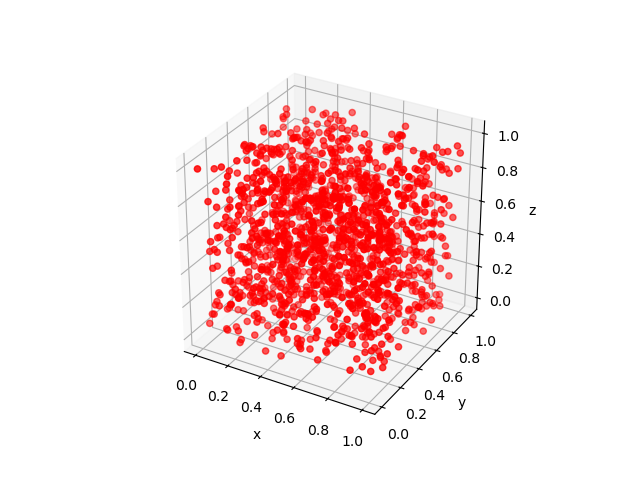

In [2]:
#Use the below command to make the plot interactive
%matplotlib ipympl   

import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d
 
#  RANDSSP Multiplicative congruential uniform random number generator.
#  Based on the parameters used by IBM's Scientific Subroutine Package.
#  The statement
#     r = randssp(m,n)
#  generates an m-by-n random matrix.
#  The function can not accept any other starting seed.
#
#  This function uses the "bad" generator parameters that IBM
#  used in several libraries in the 1960's.  There is a strong
#  serial correlation between three consecutive values.

def randssp(p,q):
    
    global m, a, c, x
        
    try: x
    except NameError:
        m = pow(2, 31)
        a = pow(2, 16) + 3
        c = 0
        x = 123456789
    
    try: p
    except NameError:
        p = 1
    try: q
    except NameError:
        q = p
    
    r = np.zeros([p,q])

    for l in range (0, q):
        for k in range (0, p):
            x = np.mod(a*x + c, m)
            r[k, l] = x/m
    
    return r


spectra = randssp(3, 1500)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_box_aspect(aspect=(1, 1, 1))

ax.scatter(spectra[0, :], spectra[1, :], spectra[2, :], color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

The scatter plot exhibits strong spatial correlation. This can clearly be seen by the structured repeating bands. The repeated banding structure means that the distribution is not uniform or random. This means that the particle positions are not independent. As is stated in the code, it was written using less-than optimal generator parameters.

This function is known as a Linear Congruential Generator (LCG) and relies on a recurrence relation. Naturally, successive values are strongly correlated and produce statistical bias when plotted in 3D space. This means they do not fill space uniformly and thus are not isotropically distributed. This means that in Monte-Carlo simulations and scattering simulations, the random number generation introduces artificial correlations. This example therefore illustrates that random number generation is not inherently random but relies on an algorithm, that in itself can introduce statistical bias which is not ideal for simulations such as neutron shielding in this project.

### Random number generator that produces samples distributed according to an exponential function
In order to simulate neutron mean-free path lengths, one needs to generate random samples that follow an exponential distribution, $\sim e^{\frac{-x}{\lambda}}$. A transformation method is needed to transform the uniform distribution to the desired probability distribution, due to the physical constraints the law of total probability requires. 

Considering the fact that probability of the particle taking up a certain position is defined as $0 < P(x) < 1$, the cumulative distribution function is used to generate samples of $x$. This is accomplished in the code below by introducing a variable $u \in [0,1)$. 

For neutron transports, the probability is  $\sim e^{\frac{-x}{\lambda}}$ so inverting the variable $u$ yields the sampling relation $\lambda \ln(u)$; it must be noted that the exponential distribution does not include $0, 1$ as it would cause a NaN error as $\ln0$ is undefined. This relationship allows neutron step lengths to be generated from a pre-packaged Python pseudo-random number generator. Below a histogram is used because they are used to represent probability distribution functions from discrete samples, which is what Monte Carlo simulations do.

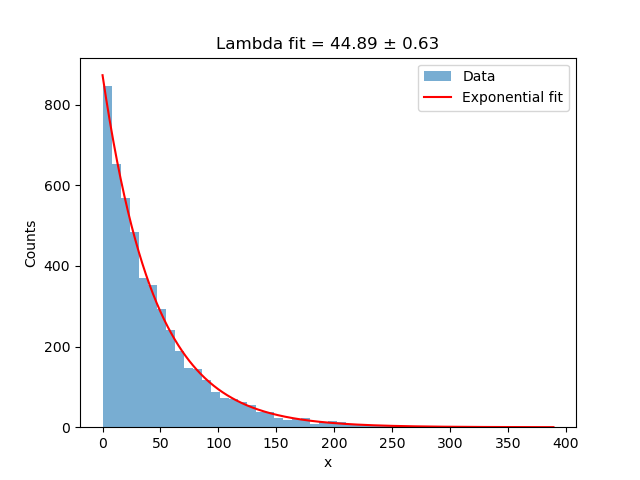

In [3]:
def exponential_dist(lamda, n):
    """
    Converts linear data into an exponential distribution.
    """
    u = np.random.uniform(1e-10, 1 - 1e-10, n) # small deviation away from 0, 1 as ln0 undefined
    x_vals = -lamda * np.log(u) # defines new distribution x 
    return x_vals

def make_histogram(x_vals, bins=50):
    """
    Convert raw data into histogram counts and bin centers.
    """
    counts, bin_edges = np.histogram(x_vals, bins=bins) # returns bin edge positions
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:]) # bin centres computed (uses length of bin and halves for centre)
    return counts, bin_centers


def prepare_for_fit(counts, bin_centers):
    """
    Remove zero bins and take logarithm as ln0 undefined.
    """
    mask = counts > 0 # keeps only values greater than 0, so ln0 is removed (ln0 undefined)
    x_fit = bin_centers[mask] # ensures 0 removed
    N_fit = counts[mask]
    log_N = np.log(N_fit) # compute logarithm

    # uncertainties in log(N): 1/sqrt(N)
    err_logN = 1 / np.sqrt(N_fit)
    
    return x_fit, log_N, err_logN

def fit_exponential(x_fit, log_N, sigma_logN):
    """
    Perform weighted linear fit to log data and returns associated errors.
    """
    weights = 1 / sigma_logN # weighting from standard deviation of the logarithm of N, where N is the number of samples taken
    coefficients, cov = np.polyfit(x_fit, log_N, 1, w=weights, cov=True) # polyfit of linear model
    gradient = coefficients[0] # gradient
    y_int = coefficients[1] # y-intercept
    
    grad_err = np.sqrt(cov[0, 0]) # error in gradient is in position (0,0) on covariance matrix
    lambda_fit = -1 / gradient # lamda calculated from fit (cm)
    lambda_err = grad_err / (gradient**2) # error in lamda

    return gradient, y_int, lambda_fit, lambda_err

lamda_true = 45 # cm (expected attenuation length)
N = 5000 # number of samples

# calls all the functions above
x_exp = exponential_dist(lamda_true, N)
count, bin_centres = make_histogram(x_exp, bins=50)
x_fit, log_N, sigma_logN = prepare_for_fit(count, bin_centres)
gradient, y_int, lambda_fit, lambda_err = fit_exponential(x_fit, log_N, sigma_logN)

# sets up histogram, plots exponential distribution
plt.figure()
plt.hist(x_exp, bins=50, alpha=0.6, label="Data")

x_smooth = np.linspace(0, max(x_exp), 500) 
y_fit = np.exp(y_int + gradient * x_smooth) # generates y values from expected fit calculated using polyfit
plt.plot(x_smooth, y_fit, 'r-', label="Exponential fit") # plots fit curve superposed on histogram

# labels and setup
plt.xlabel("x")
plt.ylabel("Counts")
plt.title(f"Lambda fit = {lambda_fit:.2f} ± {lambda_err:.2f}")
plt.legend()
plt.show()

The histogram produced from the random number generator follows the expected exponential decay distribution. The probability decreases rapidly for longer steps as the probability of survival decreases for each new step, until the neutron escapes or is absorbed. This model is thus consistent with the theoretical expectation of neutron distributions in a uniform medium.

Quantitatively speaking, the attenuation length acquired from the histogram is in close agreement with the theoretical value for water, which is $45$cm. Statistical fluctuations due to the finite sample size and binning effects introduce an error of $\frac{1}{\sqrt N}$, thus explaining the discrepancy between the theoretical and fitted values.

Overall, the simulated and theoretical values are in approximate agreement, thus validating the random number generator produced as well as the use of an exponential decay distribution.

### Isotropic unit vectors

Neutron scattering is directionally independent and approximated to be uniform in solid angles, so it is imperative that unit vectors used to model neutron scattering are isotropic. Uniformity is satisfied if there is equal probability per solid angle $d\Omega$, so to ensure the generated vectors are uniformly distributed and isotropic, one must make a trigonometric conversion. The most convenient coordinate system to do this in is spherical polar due to the symmetry of the problem, written as 

$$x = r\sin(\theta)\cos(\phi)$$
$$y = r\sin(\theta)\sin(\phi)$$
$$z = r\cos(\theta)$$; 
the radius is set to 1 so as not to worry about normalisation. $\phi$ must be in the range $[0, 2\pi]$ to ensure uniformity. Uniform sampling of $\theta$ does not correspond to equal solid angles, so instead $u=\cos(\theta)$ is introduced and must be uniform in $[-1, 1]$. The direction vectors can then be transformed so
$$x = \sqrt {1-u^2}\cos(\phi)$$
$$y = \sqrt {1-u^2}\sin(\phi)$$
$$z = u$$

This conserves the normalisation of the vectors as $x^2+y^2+z^2=1$. To verify isotropy, the generated vectors were plotted on a 3D scatter plot. The conditions for isotropy are that there are no directional biases or poles, which the distribution below should satisfy. Isotropic sampling is essential for accurately modelling neutron scattering events, where post-collision directions are assumed to be uniformly distributed in solid angle.

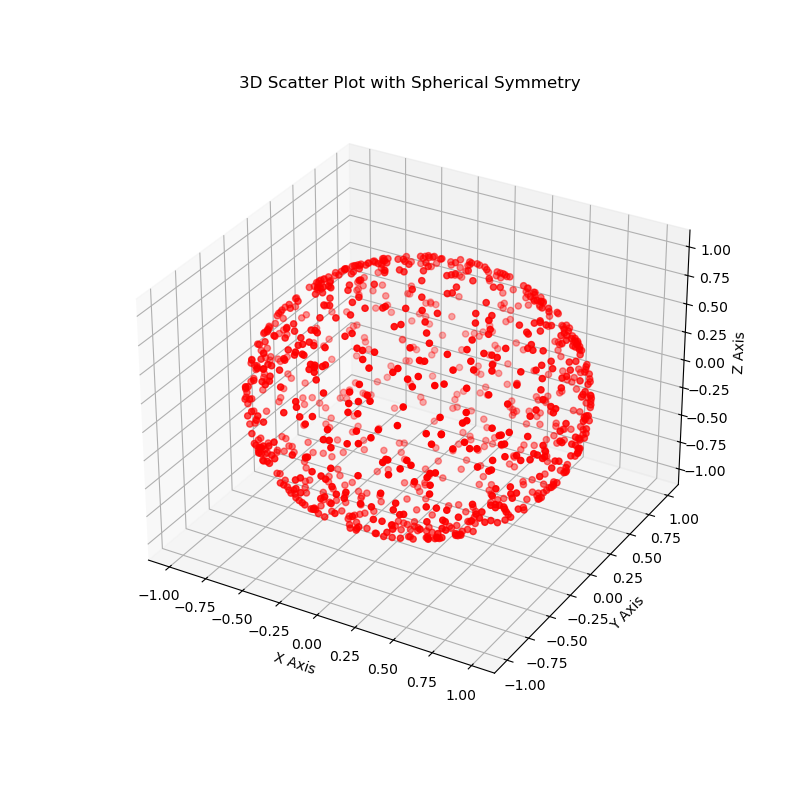

In [4]:
def isotropic_unit_vectors():
    """
    Takes in number of samples and returns isotropic unit vectors x,y, z.
    """
    
    phi = np.random.uniform(0, 2*np.pi, 1000) # 2π so it covers the entire plane
    u = np.random.uniform(-1, 1,1000)

    x = np.sqrt(1-u**2) * np.cos(phi) # trigonometric conversion as specified in the markdown above
    y = np.sqrt(1-u**2) * np.sin(phi)
    z = u

    return np.array([x, y, z]) # array that is called to 

X, Y, Z = isotropic_unit_vectors() 
fig = plt.figure(figsize=(8, 8)) # generates figure of specified size
ax = fig.add_subplot(111, projection="3d") # interactive plot
ax.scatter3D(X, Y, Z, color="red", marker="o") # scatter plot
ax.set_xlabel("X Axis") # titles and labels
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("3D Scatter Plot with Spherical Symmetry")

plt.show()

The generated direction vectors were visualised using a 3D scatter plot, allowing a qualitative analysis of isotropy. The distribution shows no preferential alignment along any axis, showing that the data is indeed uniformly distributed.

Visual inspection alone is not a rigorous test of isotropy, however no systematic clustering or directional bias is observed. This suggests that the transformation method correctly reproduces a uniform distribution on the surface of the unit sphere, meaning these directions do not defy isotropy and uniformity conditions for Monte Carlo. The absence of preferential directions is essential for accurately modelling neutron scattering, where post-collision directions are assumed to be isotropically distributed in many thermal neutron transport approximations.

This isotropic sampling, combined with exponentially distributed step lengths, ensures that the simulated neutron trajectories correctly reproduce the statistical properties of a random walk in three dimensions.

### Exponentially distributed step lengths
A neutron transport model must also account for the random nature of interaction distances. Assuming the medium is homogenous and with a constant density, the distance between successive neutron interactions follows an exponential probability distribution dominated by the bulk properties of the material, namely the mean free path. The direction and distance of neutron travel must be treated as independent stochastic variables, as by construction the two are uncorrelated. Once again this reiterates the importance of using an isotropic model. 

Neutron paths follow an exponential probability distribution as derived in previous sections. The code below transforms a uniform random variable $u\sim U(0,1)$ such that linearising yields $x= −\lambda \ln u$. This transform ensures the data is exponentially distributed.

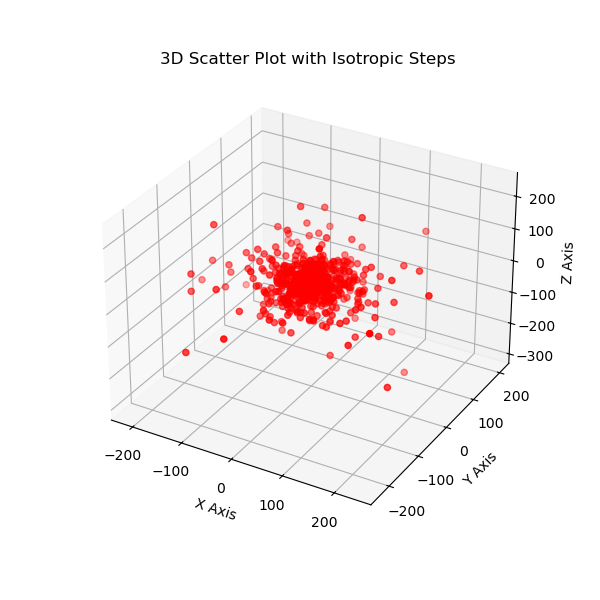

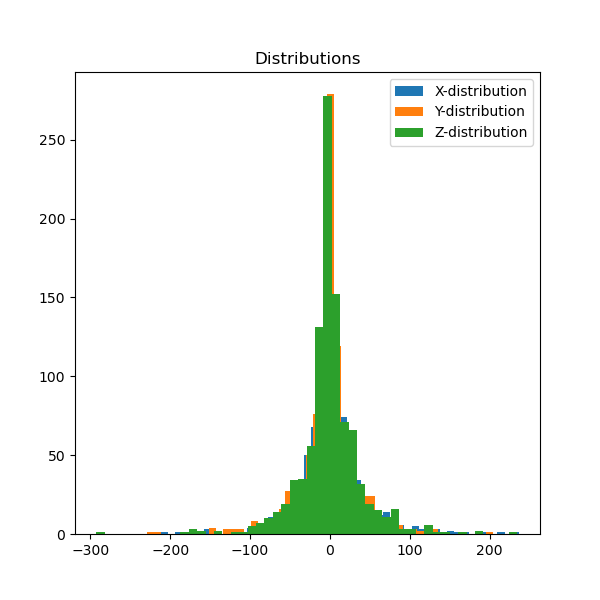

In [5]:
mean_free_path = 45 # mean free path in cm

# call necessary functions for vectors
r = exponential_dist(mean_free_path, 1000) # calls the exponential distribution created above, where 1000 is N
X, Y, Z = isotropic_unit_vectors()

# step calculation
X_step = r*X # X is the vector so r scales it, ensures they remain isotropic
Y_step = r*Y
Z_step = r*Z

fig = plt.figure(figsize=(6, 6)) # generates figure of specified size
ax = fig.add_subplot(111, projection="3d") # interactive plot
ax.scatter3D(X_step, Y_step, Z_step, color="red", marker="o") # scatter plot
ax.set_xlabel("X Axis") # titles and labels
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("3D Scatter Plot with Isotropic Steps")
plt.show()

fig = plt.figure(figsize=(6, 6))
plt.hist(X_step, bins=50, label="X-distribution") # plots a histogram of the spatial coordinates
plt.hist(Y_step, bins=50, label="Y-distribution")
plt.hist(Z_step, bins=50, label="Z-distribution")
plt.legend()

plt.title("Distributions")
plt.show()

Distributions are clearly no longer spherical in the scatter plot - this is because the vectors now have random lengths that follow an exponential decay distribution. The scatter graph now has a higher concentration of points at the centre of the shape and fewer points as we deviate from it. There is no preferred direction as the exponential distrubution ensures the point can go at any point. The scatter graph mirrors neutron shielding as it follows an exponential decay also.

The histograms are produced for illustrative purposes and reveal nothing quantitaive. All three distributions peak at $0$ and decay exponentially on either side (give or take some fluctuation). Graphing as a histogram shows that particle absorption is bell-shaped around $0$. This is likely due to the fact that the exponential distribution favours small steps but the isotropic direction ensures these steps are evenly distributed in all directions. The isotropic unit vectors means that the distribution is symmetric and Gaussian in shape, as would be expected. This means that for the remainder of the project one can use Binomial approximations for standard deviations and errors.

## Application to Monte Carlo Neutron Simulations

### Determining Material Properties
Material properties such as the microscopic cross-sections and material densities can be used to calculate the macroscopic cross sections and mean free paths. These parameters determine the probability of neutron interactions for each path undertaken, so define the stochastic transport behaviour in the Monte Carlo simulation. In depth theory is explain in the theory section, but a pertinent equation in this section is that of number density, $n$, defined as
$$n = \frac{\rho N_A}{M}$$ where $\rho$ is the density of the slab, $N_A$ is Avogadro's constant and $M$ is the molar mass. The programme then converts the number density into macroscopic cross-sections by multiplying by a factor of $10^-{24}$, so as to work in standard units as opposed to barns.

The total macroscopic cross section governs the mean free path according to:
$$\Sigma_t = \Sigma_a + \Sigma_s, \lambda = \frac{1}{\Sigma_t}$$

These quantities allow the quantisation of the attenuation length as well as absorption, reflection and transmission rates in different materials. If the model is accurate, water should have the smallest mean free path as it is hydrogenous so exhibits very strong scattering. Lead on the other hand should have a moderate mean free path as it is very dense. Further still, graphite should exhibit a mean free path of the same order as that of lead due to its low absorption cross-section and moderate scattering.

In [6]:
N_A = 6.022e23 # Avogadro's constant

def material_properties(material): # calls in material data
    """
    This function calls in the material data and returns the mean free path and the absorption and scattering cross-sections.
    """
    absorption = material[0] # barn
    scattering = material[1] # barn
    density = material[2] # g/cm^3
    molar_mass = material[3] # g/mol
    
    # number density calculation
    number_density = (density * N_A) / molar_mass
    
    # macroscopic cross-section calculations
    abs_cross_section = number_density * absorption * 1e-24 # converts data to standard units cm^-1 (originally in barns)
    sca_cross_section = number_density * scattering * 1e-24
    trans_cross_section = sca_cross_section + abs_cross_section # using equation in above markdown, as probabilities must add up to 1

    # mean free path calculation
    mean_free_path = 1 / trans_cross_section

    return abs_cross_section, sca_cross_section, mean_free_path

# data
water = [0.6652, 103, 1, 18.0153]
lead = [0.158, 11.221, 11.35, 207.2]
graphite = [0.0045, 4.74, 1.67, 12.011]

# calculates values from data using the material properties function
sigma_a_water, sigma_s_water, lambda_water = material_properties(water)
sigma_a_lead, sigma_s_lead, lambda_lead = material_properties(lead)
sigma_a_graphite, sigma_s_graphite, lambda_graphite = material_properties(graphite)

# prints calculated results in same units
print("Material Properties:")
print(f"\nWater:\n sigma_a = {sigma_a_water:.4f}/cm, sigma_s = {sigma_s_water:.4f}/cm, mean free path = {lambda_water:.4f}cm") 
print(f"Lead:\n sigma_a = {sigma_a_lead:.4f}/cm, sigma_s = {sigma_s_lead:.4f}/cm, mean free path = {lambda_lead:.4f}cm")
print(f"Graphite:\n sigma_a = {sigma_a_graphite:.4f}/cm, sigma_s = {sigma_s_graphite:.4f}/cm, mean free path = {lambda_graphite:.4f}cm")

Material Properties:

Water:
 sigma_a = 0.0222/cm, sigma_s = 3.4430/cm, mean free path = 0.2886cm
Lead:
 sigma_a = 0.0052/cm, sigma_s = 0.3702/cm, mean free path = 2.6641cm
Graphite:
 sigma_a = 0.0004/cm, sigma_s = 0.3969/cm, mean free path = 2.5173cm


Looking at the printed data above, water exhibits the shortest mean free path. A smaller mean free path indicates higher interaction probability, so water has the highest interaction probability out of all three materials. This is likely primarily due to its large scattering cross section.

In contrast, both lead and graphite have significantly large mean free paths. This indicates that neutrons travel further into these media than water. Lead's lower scattering cross section compared to water results in fewer interactions, even though it is denser.

Graphite has a similar mean free path to lead; it differs however in terms of its lower absorption cross-section, so neutrons transmit effectively.

These differences directly influence the observed shielding behaviour in the Monte Carlo simulations. The material properties calculated are thus consistent with the expected transmission cross-sections and mean free paths of graphite, water and lead.

### Neutron transport and Markov process
Neutron transport is modelled as a Markov process; each neutron at a step will undergo a change in direction and path, the two quantities completely independent from eachother. Each particle history represents the trajectory of a neutron through the material until termination by absorption, reflection from the slab or transmission out of it.

At each interaction point, the neutron either undergoes absorption, where the particle history will terminate, scattering in which the direction of the neutron's trajectory changes or a a transmission or reflection depending on the slab boundaries.

Mapping out the particle trajectories allows for the calculation of stochastic properties such as the attenuation length.

In [ ]:
def neutron_random_walk(L, mean_free_path, sigma_a, sigma_s, maximum_steps=10000):
    """
    This function uses the isotropic function to simulate Markov chains to track particle histories. It checks if the particle is absorbed,
    transmitted or scattered by comparison with position relative to the slab.
    
    Parameters:
       L: Length (int)
       mean_free_path: Mean free path (int)
       sigma_a: Absorption cross-section (int)
       sigma_s: Scattering cross-section (int)

    Returns:
       trajectory: array
       outcome: states whether the particle is absorbed, reflected or scattered (string)
       scatter_count: int
    """
    r = np.array([0.0, 0.0, 0.0])
    direction = np.array([1.0, 0.0, 0.0]) # starts in +ve x direction
    
    trajectory = [r.copy()]
    prob_absorb = sigma_a / (sigma_a + sigma_s)
    scatter_count = 0
    
    for i in range(maximum_steps):
        
        u = np.random.uniform(1e-10,1 - 1e-10)
        step = -mean_free_path * np.log(u)

        r_new = r + step*direction

        if r_new[0] < 0: # means it escaped left, checks x
            return trajectory, "reflected", scatter_count

        if r_new[0] > L: # escaped right  
            return trajectory, "transmitted", scatter_count

        trajectory.append(r_new.copy())

        if np.random.rand() < prob_absorb: # absorbed
            return trajectory, "absorbed", scatter_count

        scatter_count += 1

        # new random direction defined
        direction = isotropic_unit_vector()
        r = r_new # new starting position

    return trajectory, "max_steps", scatter_count # max steps is put in in the case of no convergence, otherwise returns abs/tras/ref

def neutron_simulation(N, L, mean_free_path, sigma_a, sigma_s):
    """
    This function simulates the scattering of a neutron using the neutron random walk function above.

    Parameters:
       N: number of neutrons (int)
       L: thickness of slab (int)

    Returns:
       trajectories: array
       num_abs: number of absorbed particles (int)
       num_ref: number of reflected particles (int)
       num_trans: number of transmitted particles (int)
    """
    
    trajectories = [] # empty trajectories array

    num_abs = 0 # initial number of particles in each bin is 0 before the particle interacts with the slab
    num_ref = 0
    num_trans = 0

    for i in range(N): # iterates the random walk function for N
        path, outcome, scatter_count = neutron_random_walk(L, mean_free_path, sigma_a, sigma_s, maximum_steps=10000) # maximum steps in case 
        trajectories.append(path)                                                                                    # convergence takes too long

        if outcome == "absorbed": # tracks what particle behaviour the particle exhibits
            num_abs += 1          # adds to the count depending on the outcome specified from the random walk

        if outcome == "reflected":
            num_ref += 1

        if outcome == "transmitted":
            num_trans += 1
            
    return trajectories, num_abs, num_ref, num_trans 

def plot_trajectories(paths, material, L, max_plot=10): # max_plot acts as a safety limit, only affects rendering
    """
    This function plots the trajectories for a material.
    
    Parameters:
       paths: array
       material: Name of material (string)
       
    Returns: 
       Plot of trajectories.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d") # scatter initialisation

    for traj in paths[:max_plot]: # max_plot ensures to loop only the first couple of max_plot trajectories, not all of them
        traj = np.array(traj)
        ax.plot(traj[:,0], traj[:,1], traj[:,2]) # ploys x, y, z using index

    ax.set_xlim(0, L) # sets limit on x axis to within constraints of the slab
    
    ax.set_xticks([0, L])
    ax.set_xticklabels(["0", "L"]) # visually shows "where" in the slab the particle is
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"3D Random Walk in {material}") 

    plt.show()
    
def isotropic_unit_vector():
    """
    Takes in number of samples and returns isotropic unit vectors x, y, z.
    """
    # x = rsinthetacosphi, y = rsinthetasinphi, z = sqrt(1-u^2)
    phi = np.random.uniform(0, 2*np.pi)
    u = np.random.uniform(-1, 1)

    x = np.sqrt(1-u**2) * np.cos(phi)
    y = np.sqrt(1-u**2) * np.sin(phi)
    z = u

    return np.array([x, y, z])

# Calls the above functions using water data.
sigma_a_water, sigma_s_water, mean_free_path_water = material_properties(water)
trajectories, _, _, _ = neutron_simulation( # ignore all other outputs other than trajectories as they are not needed here.
    N=1000,
    L=10, # slab width = 10cm here
    mean_free_path=mean_free_path_water, 
    sigma_a=sigma_a_water,
    sigma_s=sigma_s_water
)
plot_trajectories(trajectories, "Water", L=10)

# Plots the lead data.
sigma_a_lead, sigma_s_lead, mean_free_path_lead = material_properties(lead)
trajectories, _, _, _ = neutron_simulation(
    N=1000,
    L=10,
    mean_free_path=mean_free_path_lead, 
    sigma_a=sigma_a_lead,
    sigma_s=sigma_s_lead
)
plot_trajectories(trajectories, "Lead", L=10)

# Graphite
sigma_a_graphite, sigma_s_graphite, mean_free_path_graphite = material_properties(graphite)
trajectories, _, _, _ = neutron_simulation(
    N=1000,
    L=10,
    mean_free_path=mean_free_path_graphite, 
    sigma_a=sigma_a_graphite,
    sigma_s=sigma_s_graphite
)
plot_trajectories(trajectories, "Graphite", L=10)

The particle histories for all three materials show random walk behaviour. Frequent scattering at steps causes the deviation from the previous step, as can be seen in all three plots. Water has the shorter mean free path out of the three so as expected has more frequent interactions in comparison to lead and graphite. Scattering increases path length inside the slab, so the trajectories are more densely packed leading to a higher probability of absorption. This is physically intuitive as paths are distributed exponentially, with the probability of survival decreasing with every step. Graphite and lead have more infrequent interactions but transmit further into the slab due their higher transmission cross-sections.

### Quantifying Scatter Processes
Each neutron history results in a finite number of outcomes (absorption, reflection, or transmission). Since every neutron either experiences or does not experience a given outcome, the process may be modelled as a sequence of binomial trials. Statistical uncertainties are given by binomial statistics. 

It follows therefore that the statistical uncertainty be given by
$$\sigma = \sqrt {Np(1-p)}$$
and the uncertainty in the rate would be given by 
$$\sigma_p = \sqrt {\frac{Np(1-p)}{N}}$$
where $p$ in both cases is the fraction of neutrons undergoing a specific reaction mechanism and $N$ is the number of simulated neutrons.

However, because Monte Carlo methods involve stochastic sampling, each simulation was repeated in full a number of times. This allowed for the calculation of mean interaction rates from the ensemble average of repeated simulations. The spread between repeated runs provided an empirical estimate of the Monte Carlo uncertainty. This was done in order to both justify and quantify the statistical fluctuations in the distribution.

In [28]:
repeats = 3

def repeated_simulation(repeats, N, L, mean_free_path, sigma_a, sigma_s):
    """
    Parameters:
       repeats: number of times the simulation is repeated (int)

    Returns:
       results: dictionary that encloses the rates for each process, material and associated errors. (dict)
    """

    abs_counts = [] # empty array for absorbed neutrons
    ref_counts = [] # empty array for reflected neutrons
    trans_counts = [] # empty array for transmitted neutrons

    for i in range(repeats): # iterates over number of repeats in order to find a mean (as Monte Carlo simulations are subject to statistical
                             # fluctuations)
        _, num_abs, num_ref, num_trans = neutron_simulation(N, L, mean_free_path, sigma_a, sigma_s) # calls neutron simulation without trajectories
        abs_counts.append(num_abs) # appends to arrays
        ref_counts.append(num_ref)
        trans_counts.append(num_trans)
    
    # Calculate rates and statistics
    abs_rates = np.array(abs_counts) / N # rates are all defined by count/N
    ref_rates = np.array(ref_counts) / N
    trans_rates = np.array(trans_counts) / N
    
    results = { # results added to a results dictionary
        "absorption": (np.mean(abs_rates), np.std(abs_rates, ddof=1)), # calculates mean rates from all arrays from different iterations
        "reflection": (np.mean(ref_rates), np.std(ref_rates, ddof=1)),
        "transmission": (np.mean(trans_rates), np.std(trans_rates, ddof=1))
    }
    
    return results

L = 10 # thickness in cm
N = 1000 # number of neutrons

# Water results
water_results = repeated_simulation(
    repeats=repeats,
    N=N,
    L=L,
    mean_free_path=mean_free_path_water,
    sigma_a=sigma_a_water,
    sigma_s=sigma_s_water
)

abs_water_rate, unc_abs_w = water_results["absorption"] # absorption rate and error for water
ref_water_rate, unc_ref_w = water_results["reflection"] # reflection rate and error
trans_water_rate, unc_trans_w = water_results["transmission"] # transmitted rate and errors

# Lead results
lead_results = repeated_simulation(
    repeats=repeats,
    N=N,
    L=L,
    mean_free_path=mean_free_path_lead,
    sigma_a=sigma_a_lead,
    sigma_s=sigma_s_lead
)
# returns lead rates and errors 
abs_lead_rate, unc_abs_l = lead_results["absorption"] 
ref_lead_rate, unc_ref_l = lead_results["reflection"]
trans_lead_rate, unc_trans_l = lead_results["transmission"]

# Graphite
graphite_results = repeated_simulation(
    repeats=repeats,
    N=N,
    L=L,
    mean_free_path=mean_free_path_graphite,
    sigma_a=sigma_a_graphite,
    sigma_s=sigma_s_graphite
)
# graphite rates and errors
abs_graph_rate, unc_abs_g = graphite_results["absorption"]
ref_graph_rate, unc_ref_g = graphite_results["reflection"]
trans_graph_rate, unc_trans_g = graphite_results["transmission"]

# Print results
print("Rates with error")
print(f"\nWater:\n Absorption = {abs_water_rate:.4f}±{unc_abs_w:.4f}, Reflection = {ref_water_rate:.4f}±{unc_ref_w:.4f}, Transmission = {trans_water_rate:.4f}±{unc_trans_w:.4f}")
print(f"Lead:\n Absorption = {abs_lead_rate:.4f}±{unc_abs_l:.4f}, Reflection = {ref_lead_rate:.4f}±{unc_ref_l:.4f}, Transmission = {trans_lead_rate:.4f}±{unc_trans_l:.4f}")
print(f"Graphite:\n Absorption = {abs_graph_rate:.4f}±{unc_abs_g:.4f}, Reflection = {ref_graph_rate:.4f}±{unc_ref_g:.4f}, Transmission = {trans_graph_rate:.4f}±{unc_trans_g:.4f}")

Rates with error

Water:
 Absorption = 0.1930±0.0044, Reflection = 0.8043±0.0061, Transmission = 0.0027±0.0029
Lead:
 Absorption = 0.1077±0.0085, Reflection = 0.6223±0.0070, Transmission = 0.2700±0.0036
Graphite:
 Absorption = 0.0080±0.0044, Reflection = 0.6760±0.0121, Transmission = 0.3160±0.0095


Water shows a very high reflection probability, of the order $0.8$ for each iteration, indicating that there are frequent particle interactions. This causes the neutrons in the water slab to undergo highly diffusive random walks before absorption or reflection through the slab. This deduction fits the theoretical expectation, as indeed water has a relatively short mean free path so scatters frequently. This is because neutrons travel only short distances between collisions.

Lead exhibits a higher transmission probability compared to water. This is consistent with its larger mean free path, as it means random walk paths are longer so scattering events are less frequent. Lead exhibits a significantly larger transmission probability than water. Consequently, neutron paths are less diffusive and instead travel further into the slab.

Graphite shows relatively low absorption and moderate transmission, indicating that neutrons can travel a distance within the material.This behaviour is consistent with random-walk trajectories provided in the Markov chain analysis, as the graphite particle history shows extended transport with fewer losses due to absorption. 

Overall, the interaction probabilities calculated are physically consistent with those predicted by the simulation. The Monte Carlo implementation reproduces the expected qualitative behaviour of neutron transport, as there is a clear dependence on cross-section and mean free path.

### Plotting Variations

The variation of neutron absorption, reflection and transmission probabilities with slab thickness is investigated below for water, graphite and lead. It is to be expected that as slab thickness increases, neutrons have more opportunity to scatter, thus greatly altering the transmission, absorption and scattering rates. However, the three mechanisms are also governed by cross-sections and mean free paths, so it is to be expected that each material will have different interaction rates as $L$ changes.

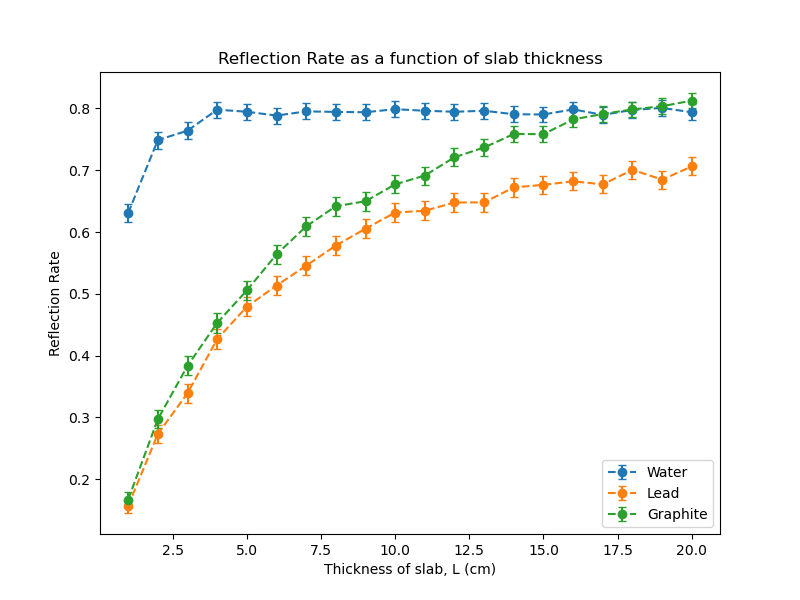

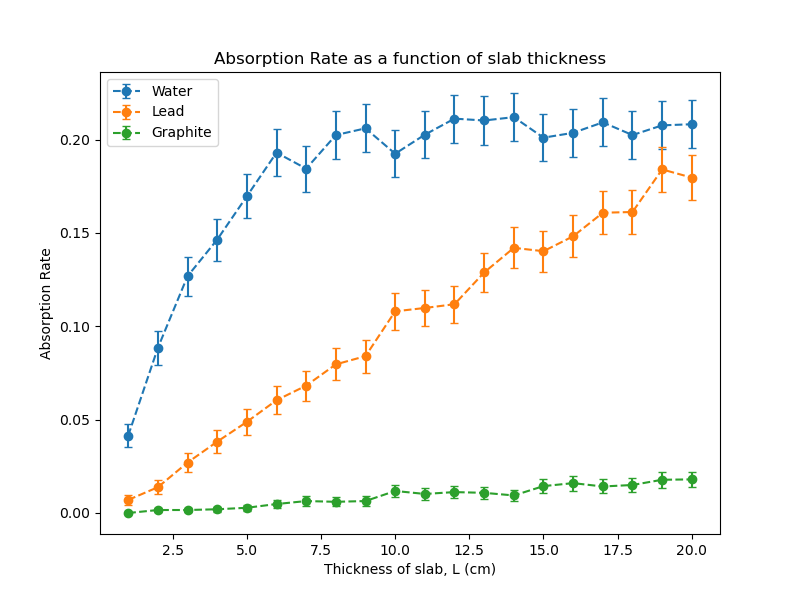

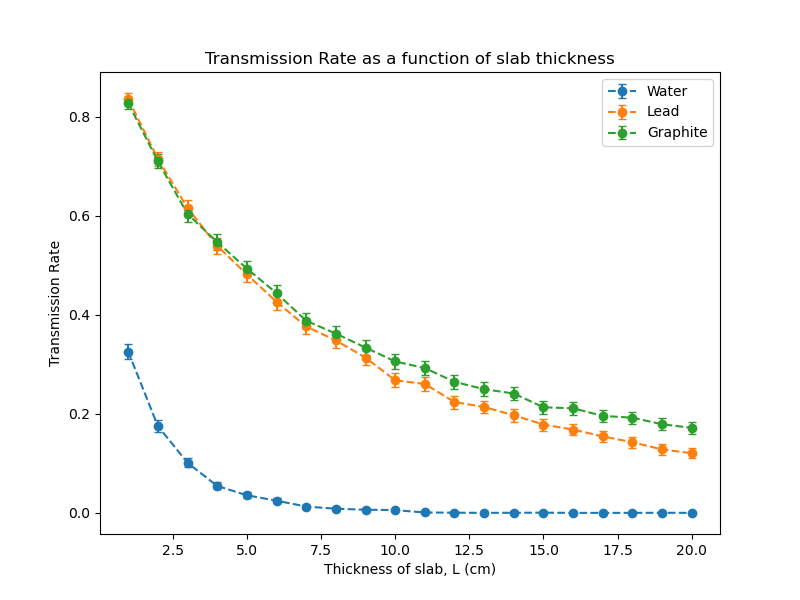

In [29]:
def rate_variation(process, repeats=3, N=1000):
    """
    This function returns rates for different mechanisms as a function of slab thickness.
    
    Parameters:
       process: interaction mechanism ("string")
    Returns:
       results (dict)
    """

    results = {} # results dictionary, empty here
    
    L_array = np.arange(1, 21) # array for slab thickness allows a sweep of these values.
    
    materials = { # materials dictionary encloses cross sections (absorption/scattering) and mean free path
        "Water": (sigma_a_water, sigma_s_water, mean_free_path_water),
        "Lead": (sigma_a_lead, sigma_s_lead, mean_free_path_lead),
        "Graphite": (sigma_a_graphite, sigma_s_graphite, mean_free_path_graphite)
    }
    
    for material_name, properties in materials.items(): # iterates over number items in materials dictionary
        sigma_a, sigma_s, mean_free_path = properties 
        
        rate_array = [] # array for each mechanism rate
        uncertainty_array = [] # uncertainty associated with each mechanism rate

        for L in L_array: # iterates over all the thickness values
            sim_results = repeated_simulation(
                repeats,    
                N,          
                L,
                mean_free_path,
                sigma_a,
                sigma_s
            )
            
            mean_rate, std_rate = sim_results[process] # mean and standard deviation
            rate_array.append(mean_rate) # append the mean rate for each thickness iterated "repeat" amount of times

            # binomial for error used her since number of repetitions is small
            sigma = np.sqrt(mean_rate * (1 - mean_rate) / N) # formula for standard deviation for binomial
            uncertainty_array.append(sigma)
            
        results[material_name] = (L_array, rate_array, uncertainty_array) # assigns values to results dictionary
    
    return results
    
def plot_rate_variations(results, process):
    """
    This function plots each mechanism, with the three materials on the same graph. It demonstrates the variation of each mechanism rate as 
    a function of slab thickness.
    """
    fig, ax = plt.subplots(figsize=(8,6)) # initialises figure
    
    for material_name, data in results.items(): # iterates over data
        L_array, rate_array, uncertainty_array = data
        ax.errorbar(L_array, rate_array, yerr=uncertainty_array, marker="o", capsize=3, linestyle="--", label=material_name) # errorbars included
        
    ax.set_xlabel("Thickness of slab, L (cm)")
    ax.set_ylabel(f"{process.capitalize()} Rate") 
    ax.set_title(f"{process.capitalize()} Rate as a function of slab thickness")

    ax.legend()
    plt.show()
        
reflection_results = rate_variation("reflection", repeats=5, N=1000) # reflection rates calculated for each material
plot_rate_variations(reflection_results, "reflection") # reflection rates as a function of slab thickness plotted (all materials on same graph)

absorption_results = rate_variation("absorption", repeats=5, N=1000) # absorption rates calculated
plot_rate_variations(absorption_results, "absorption") # absorption vs L plot

transmission_results = rate_variation("transmission", repeats=5, N=1000) # transmission rates calculated
plot_rate_variations(transmission_results, "transmission") # transmission vs L plot

The transmission curves show clear exponential attenuation with increasing slab thickness. This agrees with the Beer-Lambert law, as it is expected that the probability of transmission decreases with slab width as scattering dominates. In the slab, the neutron penetrates deeper and the probability of surviving without undergoing scattering decays exponentially. This is because as the material thickness increases, particle interactions increase in likelihood. Transmission probability therefore decreases according to $\sim e^-\frac{L}{\lambda}$. 

Water exhibits the steepest transmission decay. This strong attenuation is consistent with the theory discussed in prior sections as water has the shortest mean free path, therefore will have more frequent scattering. This effect is only exacerbated as the thickness $L$ increases. Neutrons travelling through a slab of water of thickness $L$ scatter very frequently in a short distance (see the particle history plot for water for visual evidence), which increases the probability of removal through scattering or absorption.

Lead and graphite on the other hand have a lower rate of transmission decay, which is as to be expected due to their relatively larger attenuation lengths. In both materials, the neutrons can travel greater distances between successive interactions due to infrequent scattering. In consequence, the neutrons penetrate further into the slab without absorption. In particular, graphite appears to maintain a higher rate of transmission in comparison to the other two materials, likely showing graphite has poor absorption.

On the other hand, the absorption and reflection probabilities do not undergo exponential decay. Absorption and reflection are not survival probabilties so it makes physical sense that they do not decrease. This is reliant on the fact that the probability of a neutron surviving decays exponentially for every step. As $L$ increases neutrons scatter more such that the probability of absorption and reflection increase non-linearly. At a certain point on the graphs they appear to plateau, likely reaching some sort of saturation limit. This is a lot more evident for reflection than it is for absorption.

The reflection curves increase rapidly initially before tending to plateau at larger $L$. The physical interpretation is that the likelihood of neutrons scattering back increases rapidly for small increases in thickness. However, at a large enough thickness the neutrons will have already undergone a plethora of random walks and the reflection probability cannot increase indefinitely. Water has the slowest increase in reflection rate, likely due to the fact that in comparison to the lead and graphite is of the order $\mathcal O^2$ larger. Graphite on the other hand has the steepest increase in reflection rate due to its poor absorptive qualities.

Generally, the absorption increases with slab thickness. Longer path lengths increase the likelihood of a neutron being absorbed. Much like this reflection curve, at sufficiently large thicknesses absorption probabilities also begin to saturate.

Statistical uncertainties associated with the transmission curve increase noticeably. This occurs due to the decreasing number of neutrons transmited, which reduces the number of events sampled so uncertainties increase accordingly. Since Monte Carlo uncertainties scale with Poisson counting statistics, smaller transmissions as slab width increases produce more noticeable error fluctuations. This is evident in fluctuation of error bar sizes in all three curves. These fluctuations are most pronounced in the absorption curves, particularly that of water, as scattering dominates.

Overall, the behaviour of the transmission, absorption and reflection curves mirror the behaviours expected from a neutron scattering experiment. The exponential attenuation of transmission as well as the non-linear growth of the scattering curves confirms that the Monte Carlo random-walk is statistically accurate.

### Determining Attenuation Lengths

For all materials, transmission decreases as slab thickness increases. The attenuation of particles travelling through a medium of constant density is shown in the equation below
$$T(L)=T_0 e^{-\frac{L}{\lambda}}$$
where $T(L)$ is the transmission, $T_0$ is the transmission at zero thickness, $L$ is the thickness and $\lambda$ is the thickness of the slab. Taking the natural log linearises the relationship, yielding
$$\ln(T) = \ln(T_0)-\frac{L}{\lambda}.$$
This predicts that if the model is accurate, $ln(T)$ against $L$ produces a straight line with gradient $-\frac{1}{\lambda}$, allowing the attenuation length to be extracted directly from a weighted linear fit. It is to be expected that the attenuation for water will be significantly smaller than that of graphite and lead, the latter instead comparable to eachother.

In [30]:
def attenuation_length(results, material_name):
    """
    This function linearises Beer-Lambert's law in order to use polyfit; from this the attenuation and its error is calculated.
    """
    N = 1000
    
    L_array, transmission_mean, _ = results[material_name] # only use transmission rates
    transmission_mean = np.array(transmission_mean) # convert to numpy array
    mask = transmission_mean > 0 # removes 0 so no NaN errors occur, this mask is applied to the arrays later 
    
    L_fit = np.array(L_array)[mask] # fitted data used 
    rate_fit = np.array(transmission_mean)[mask] # fitted array data
    error_fit = np.sqrt(rate_fit * (1 - rate_fit) / N)[mask] # standard deviation from binomial theorem

    log_rate = np.log(rate_fit) # take logarithm to linearise
    
    # uncertainty propagation
    sigma_log_rate = error_fit / rate_fit

    weights = 1.0 / (sigma_log_rate ** 2) # weighting used for covariance matrix

    # linear fit to determine attenuation
    coefficients, covariance = np.polyfit(
        L_fit,
        log_rate,
        1,
        w=np.sqrt(weights),
        cov=True
    )

    gradient = coefficients[0]
    intercept = coefficients[1]
    gradient_err = np.sqrt(covariance[0,0])

    # attenuation from linear model
    attenuation = -1 / gradient
    # attenuation error
    attenuation_err = gradient_err / gradient**2

    fit_line = gradient * L_fit + intercept   # fitted line
    residuals = log_rate - fit_line # difference from fitted line to the actual graph

    chi2 = np.sum((residuals / sigma_log_rate) ** 2)
    dof = len(L_fit) - 2 # dof = degrees of freedom
    chi2_red = chi2 / dof # reduced chi squared

    return {
        "L": L_fit,
        "log_rate": log_rate,
        "sigma_log_rate": sigma_log_rate,
        "fit_line": fit_line,
        "residuals": residuals,
        "attenuation": attenuation,
        "attenuation_err": attenuation_err,
        "chi2_red": chi2_red
    }

# calls the function for the three materials
water_fit = attenuation_length(transmission_results, "Water") 
lead_fit = attenuation_length(transmission_results, "Lead")
graphite_fit = attenuation_length(transmission_results, "Graphite")

# Plot
fig, axes = plt.subplots(3, 2, figsize=(10, 10)) # generates figure

fits = [("Water", water_fit),
        ("Lead", lead_fit),
        ("Graphite", graphite_fit)
       ]

for i, (material, fit) in enumerate(fits): 
    L = fit["L"]
    log_rate = fit["log_rate"]
    sigma = fit["sigma_log_rate"]
    line = fit["fit_line"]
    residuals = fit["residuals"]
    
    # left column has main/linear fit
    axes[i,0].errorbar(L, log_rate, yerr=sigma, marker='o', capsize=3, linestyle='--')
    axes[i,0].plot(L, line, label='Linear Fit')
    axes[i,0].set_ylabel("ln(T)")
    axes[i,0].set_title(f"{material} Fit")
    axes[i,0].legend()

    # residuals for each on right column
    axes[i,1].axhline(0, linestyle='--')
    axes[i,1].errorbar(L, residuals, yerr=sigma, marker='o', capsize=3, linestyle='none')
    axes[i,1].set_ylabel("Residual")
    axes[i,1].set_title(f"{material}: χ²ᵣ= {fit['chi2_red']:.2f}") # reduced chi squared added on the residual plot

# bottom x labels only
axes[2,0].set_xlabel("Slab Thickness L (cm)")
axes[2,1].set_xlabel("Slab Thickness L (cm)")

plt.tight_layout()
plt.show()

# Prints the attenuation results with reduced chi squared as a goodness of fit parameter
print("Attenuation Results with associated errors:")
print(f"\nWater: {water_fit["attenuation"]:.4f}±{water_fit["attenuation_err"]:.4f}, χ²ᵣ={water_fit["chi2_red"]:.2f}")
print(f"Lead: {lead_fit["attenuation"]:.4f}±{lead_fit["attenuation_err"]:.4f}, χ²ᵣ={lead_fit['chi2_red']:.2f}")
print(f"Graphite: {graphite_fit["attenuation"]:.4f}±{graphite_fit["attenuation_err"]:.4f}, χ²ᵣ={graphite_fit['chi2_red']:.2f}")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 15 but corresponding boolean dimension is 20

Water exhibits the smallest attenuation length. This means it has the most rapid attenuation with increasing slab thickness. Physically, this is as expected because water possesses the shortest mean free path out of all three materials. Over short distances, neutrons undergo more collisions which in turn increases the chance of reflection or absorption before it is transmitted through the slab.

Graphite is calculated to have the largest attenuation length overall, consistent with its relatively low absorption probability. This means that neutrons travel further in the graphite slab before the probability of transmission decreases appreciably. This is because, though scattering still occurs, neutrons are less likely to be removed, so penetrate deeper.

Calculating the reduced chi-squared provides a measure of goodness-of-fit between the linear model and the Monte Carlo simulation method. Values close to $1$ imply that the model accurately describes the system and that the error fluctuations have been propagated accurately.

The reduced chi-squared values for both water and lead are very close to $1$; this indicates excellent agreement between the exponential model and the Monte Carlo simulation. The neutron transport process within these materials is thus well described by exponential attenuation.

Graphite however returns a slightly higher reduced chi-squared value in comparison. Statistical uncertainties may be slightly underestimated and thus are causing these fluctuations. It must be noted that Monte Carlo simulations are subject to stochastic fluctuations, which has been minimised by repeating the simulations a number of times to find a mean and standard deviation. These statistical fluctuations are also evident in the resiudal plots for all three graphs.

Overall, the fitted exponential curve is in agreement with the physics behind scattering mechanisms and the reduced chi-squared analysis and residual plots mirror this.

### Woodcock Method
Woodcock tracking is a particle-tracking technique commonly used in simulations such as neutron transport. This method is useful for simulations pertaining to multiple materials with differing interaction cross-sections.

In previous parts of the project where the Monte Carlo method was used, neutron trajectories must be compared to the boundary for each step. For this project where the number of neutrons is not high, it is not taxing on the computer. However, this can become computationally expensive rapidly for systems where there are many particle interactions as it must check which material the particle is occupying, as well as where the next boundary is.

Woodcock tracking avoids this repeated boundary checking by introducing a fictitious total cross section. A step length is then sampled using this maximum cross section, as opposed to the local material cross section. An algorithm then determines whether the collision with the boundary is physical or a fictitious one.

The probability $P(r)$ is given by 
$$P(r) = \frac{\Sigma(r)}{\Sigma_{max}} $$
where $\Sigma(r)$ is the local macroscopic cross section at position r and $\Sigma_{max}$ is the global cross section.

If the interaction is rejected, the particle continues travelling. The process repeats as such until absorption or escape out of the media.

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact # interactive widgets used to toggle slab thickness

materials_dict = {
    "Water": material_properties(water),
    "Lead": material_properties(lead),
    "Graphite": material_properties(graphite)
}

def material_sigma(x, L, sigma_1_a, sigma_1_s, sigma_2_a, sigma_2_s):
    """
    This function tracks the position of the neutron. Depending on its position (i.e. if it has hit a boundary), the transmission cross-section is
    calculated.
    
    Parameters:
      x = position of neutron (int)
      L = slab thickness (int)
      sigma_1_a = absorption cross section of material 1 (int)
      sigma_1_s = scattering cross section of material 1 (int)
      sigma_2_a = absorption cross section of material 2 (int)
      sigma_2_s = scattering cross section of material 2 (int)
      
    Returns:
      sigma_1_total or sigma_2_total (both int)
    """
    if x < L/2: # the particle would be in material 1 here, so the transmission cross-section is the absorption + scattering in material 1
        sigma_1_total = sigma_1_a + sigma_1_s
        return sigma_1_total
    else: # the particle would be in material 2 here, so the transmission cross-section is the absorption + scattering in material 2
        sigma_2_total = sigma_2_a + sigma_2_s 
        return sigma_2_total

def woodcock_parameter(L, sigma_1_a, sigma_1_s, sigma_2_a, sigma_2_s):
    """
    Simulates neutron scattering using Woodcock method. This function solely determines the paths.
    """
    max_steps = 1000 # safety measure in case it does not converge
    
    r = np.array([0, 0, 0]) # initial position
    direction = isotropic_unit_vector() 
    trajectory = [r.copy()] # trajectory array initialised
    
    sigma_max = max(sigma_1_a + sigma_1_s, sigma_2_a + sigma_2_s) # maximum sigma denotes the possible transmission cross-sections
    count = 0
    
    for steps in range(max_steps): # iterates over steps
        
        step = -np.log(np.random.rand()) / sigma_max
        r_new = r + step * direction # next step in neutron path
        
        if r_new[0] < 0: # goes back on the x-axis so reflected
            return trajectory, "reflected"

        elif r_new[0] > L: # moves in the positive x-axis so reflected
            return trajectory, "transmitted"

        sigma_local = material_sigma(r_new[0], L, sigma_1_a, sigma_1_s, sigma_2_a, sigma_2_s) # refers to the cross-section used at that point in
                                                                                              # neutron's travel
        # this checks if the path is a fictitious path or not
        if np.random.rand() < sigma_local / sigma_max:

            sigma_a_local = sigma_1_a if r_new[0] < L/2 else sigma_2_a # checks if we are in material 1 or 2 and sets the absorption cross-section
            sigma_s_local = sigma_1_s if r_new[0] < L/2 else sigma_2_s # checks if we are in material 1 or 2 and sets the transmission cross-section
            sigma_tot_local = sigma_a_local + sigma_s_local # the transmission coefficient is therefore simply the absorption + scattering
            
            if np.random.rand() < sigma_tot_local / sigma_max:

                if np.random.rand() < sigma_a_local / sigma_tot_local: # checks if the particle is absorbed
                    trajectory.append(r_new.copy())
                    return trajectory, "absorbed" # if the neutron is absorbed, the path ends
            
            direction = isotropic_unit_vector() # new direction defined

        r = r_new
        trajectory.append(r.copy()) # appends to trajectory array
    
    return trajectory, outcome # once the particle is absorbed the trajectory is returned

def woodcock_simulation(N, L, sigma_1_a, sigma_1_s, sigma_2_a, sigma_2_s):
    """
    Runs a Woodcock Monte Carlo simulation for particle transport through a two-region slab geometry. Particles are launched from x = 0 
    and tracked until they are either absorbed, reflected, or transmitted at x = L.
    """
    trajectories = []
    # initial number of particles in each bin
    num_abs = 0 
    num_ref = 0
    num_trans = 0

    for count in range(N): # iterates over N
        trajectory, outcome = woodcock_parameter(L, sigma_1_a, sigma_1_s, sigma_2_a, sigma_2_s)
        trajectories.append(trajectory)

        if outcome == "absorbed": # depending on the outcome a count is added to the corresponding bin
            num_abs +=1
        elif outcome == "reflected":
            num_ref +=1
        elif outcome == "transmitted":
            num_trans +=1

    return trajectories, num_abs, num_ref, num_trans # returns the number of particles in each bin
    
def plot_woodcock(paths, L, materials):
    """
    Visualises particle trajectories from a Woodcock Monte Carlo simulation in 3D space.

    Parameters: 
       paths: List of particle trajectories in 3D (list)
       L: slab thickness used to set plot boundaries.
       materials: label describing the material configuration (string)
       
    Returns
    """
    # generates plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    for trajectory in paths: # iterates over trajectories in path list
        if len(trajectory) == 0: # if there is not data the function stops here
            continue
            
        trajectory = np.array(trajectory) 
        ax.plot(trajectory[:,0], trajectory[:,1], trajectory[:,2]) # plots x, y, z position of the particle

    ax.set_xlim(0, L) # sets x-axis limit
    ax.set_xticks([0, L])
    ax.set_xticklabels(["0", "L"])
    
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"3D Random Walk in {materials} Woodcock Method")

    plt.show()

def interactive_woodcock(material_1, material_2, L):
    """
    Interactive Woodcock simulation comparing particle transport between two materials in a slab.

    This function:
    - Generates and plots sample particle trajectories
    - Runs a full Monte Carlo simulation
    - Computes absorption, reflection and transmission probabilities
    - Estimates an effective attenuation coefficient using exponential fitting with associated error
    """
    sigma_1_a, sigma_1_s, _ = materials_dict[material_1]
    sigma_2_a, sigma_2_s, _ = materials_dict[material_2]

    trajectories = []
    for i in range(100): # iterates woodcock method
        traj, outcome = woodcock_parameter(L,
                              sigma_1_a, sigma_1_s,
                              sigma_2_a, sigma_2_s
                              )
        trajectories.append(traj)

    plot_woodcock(trajectories, L, f"{material_1}-{material_2}") # plots woodcock for the two-material slab
    transmission = []

    L_array = np.linspace(1, 21) # thicknesses to be sweeped over

    for L in L_array:  # this for loop iterates over the thickness array and the number of particles in each bin is found
        _, num_abs, num_ref, num_trans = woodcock_simulation(N, L, sigma_1_a, sigma_1_s, sigma_2_a, sigma_2_s) 
        transmission.append(num_trans / N)  # transmission rate is the number of transmitted particles divided by N; this is appended to the array                                                              

    transmission = np.array(transmission)
    mask = transmission > 0 # removes invalid values as rate is 0 < T < 1

    L_fit = np.array(L_array)[mask] # linearises the data as was done in the neutron simulation prior
    log_T = np.log(transmission[mask])

    slope, intercept = np.polyfit(L_fit, log_T, 1)
    attenuation = -1 / slope
    
    # rates calculated for each mechanism
    abs_rate = num_abs / N 
    ref_rate = num_ref / N
    trans_rate = num_trans / N

    # uncertainty in rates found using binomial statistics since we are in the low iteration limit
    abs_unc = np.sqrt(abs_rate * (1 - abs_rate)/N)
    ref_unc = np.sqrt(ref_rate * (1 - ref_rate)/N)
    trans_unc = np.sqrt(trans_rate * (1 - trans_rate)/N)

    # prints the results
    print(f"Rates in {material_1}-{material_2}")
    print(f"Absorption = {abs_rate:.4f} ± {abs_unc:.4f}")
    print(f"Reflection = {ref_rate:.4f} ± {ref_unc:.4f}")
    print(f"Transmission = {trans_rate:.4f} ± {trans_unc:.4f}")
    print(f"Attenuation = {attenuation:.4f}")
    
    return sigma_1_a, sigma_1_s, attenuation

# this block of code allows the user to change the slab thickness as well as the two materials.
_ = interact(
    interactive_woodcock,
    material_1=widgets.Dropdown( 
        options=["Water", "Lead", "Graphite"], # user can pick material 1 between the three provided using a dropdown menu
        description="Material 1"
        ),
    material_2=widgets.Dropdown(
        options=["Water", "Lead", "Graphite"], # user can pick material 2 between the three provided using a dropdown menu
        description="Material 2"
        ),

    L=widgets.FloatSlider( # slider widget allows the user to pick the thickness of the slab (between 5-20 inclusive)
        min=5,
        max=20, 
        step=1,
        description="Slab length L (cm)"
        )
    )

Woodcock tracking is still physically consistent with neutron scattering in a shielding layer. It simplifies transport through heterogeneous systems because particles no longer need to be tracked at every step and compared to the slab boundaries. Geometrically speaking, the program is simplified significantly. 

Computational efficiency is also improved as boundary tracking often dominates the runtime, slowing down the simulation substantially. Woodcock tracking is widely used in reactor assemblies with many material interfaces.This is because the neutron interactions are random and within a boundary. The method is therefore efficient as it simplifies greatly the geometry of neutron interactions through media interfaces.

## Conclusion
The Monte Carlo simulation successfully reproduced the expected qualitative behaviour of neutron transport in matter. Water showed strong attenuation and high reflection probabilities due to its short mean free path. Lead and graphite demonstrated larger transmission probabilities and weaker attenuatiob due to higher mean free paths. In particular showed comparatively low absorption such that neutrons can penetrate deeper into the material.

Transmission, reflection and absorption probabilities were investigated systematically by sweeping through an array of slab thicknesses to determine to what level they were dependent. Transmission probabilities were clearly exponentially attenuated consistent with theory. Reflection and absorption probabilities on the other hand increased non-linearly until saturation is reached; this is because probabilities can only increase to a finite level.

Fitted attenuation lengths satisfy the goodness of fit test, as respective reduced chi-squared values close to $1$. This test demonstrates good agreement between the Monte Carlo results and the exponential attenuation model. Residual analysis further demonstrates that, though the errors do clearly fluctuate, this is due to Poisson counting statistics. These tatistical uncertainties were quantified using both binomial statistics and repeated Monte Carlo simulations. This was done to calculate means and standard deviations, which reduced error fluctuations.

Finally, the Woodcock method was discussed as a way to simplify the geometry in multiple interface systems, thus significantly improving computational efficiency.

To conclude, the consistency observed between the microscopic simulations and the macroscopic attenuation law confirms the validity of Monte Carlo techniques in modelling neutron scattering through a shielding layer.

### Bibliography
[1] P. A. W. Lewis, A. S. Goodman, and J. M. Miller, “A pseudo-random number generator for the System/360,” IBM Systems Journal, vol. 8, no. 2, pp. 136–146, 1969, doi: https://doi.org/10.1147/sj.82.0136.

[2] “Shielding of Neutron Radiation | Types & Uses | nuclear-power.com,” Nuclear Power. https://www.nuclear-power.com/nuclear-power/reactor-physics/atomic-nuclear-physics/fundamental-particles/neutron/shielding-neutron-radiation/

[3] G. S. M. Ahmed, “Neutron shielding: Advanced mechanisms, challenges, and material strategies,” Radiation Physics and Chemistry, vol. 241, p. 113544, Dec. 2025, doi: https://doi.org/10.1016/j.radphyschem.2025.113544.

‌[4] L. W. G. Morgan and D. Kotlyar, “Weighted-delta-tracking for Monte Carlo particle transport,” Annals of Nuclear Energy, vol. 85, pp. 1184–1188, Nov. 2015, doi: https://doi.org/10.1016/j.anucene.2015.07.038.

## Bibliography
[1] G. S. M. Ahmed, “Neutron shielding: Advanced mechanisms, challenges, and material strategies,” Radiation Physics and Chemistry, vol. 241, p. 113544, Dec. 2025, doi: https://doi.org/10.1016/j.radphyschem.2025.113544.

[2] “Shielding of Neutron Radiation | Types & Uses | nuclear-power.com,” Nuclear Power. https://www.nuclear-power.com/nuclear-power/reactor-physics/atomic-nuclear-physics/fundamental-particles/neutron/shielding-neutron-radiation/

[3] P. A. W. Lewis, A. S. Goodman, and J. M. Miller, “A pseudo-random number generator for the System/360,” IBM Systems Journal, vol. 8, no. 2, pp. 136–146, 1969, doi: https://doi.org/10.1147/sj.82.0136.

[4] L. W. G. Morgan and D. Kotlyar, “Weighted-delta-tracking for Monte Carlo particle transport,” Annals of Nuclear Energy, vol. 85, pp. 1184–1188, Nov. 2015, doi: https://doi.org/10.1016/j.anucene.2015.07.038.